# Oman Ministry of Health - Annual Health Reports

This notebook demonstrates how to access health statistics from the **Sultanate of Oman Ministry of Health (MOH)** Annual Health Reports.

**Data Sources:**
- **Annual Health Reports** - Comprehensive health statistics (1983/84 - present)
- **Morbidity and Mortality Data** - Disease-specific case counts and deaths (Chapter 9)
- **Health Status Indicators** - Life expectancy, infant mortality, immunization (Chapter 2)
- **Health Service Utilization** - Outpatient visits, hospital admissions, bed occupancy (Chapter 7)
- **Governorate-level Data** - Subnational health statistics by region

**Coverage:**
- **Geographic**: 11 governorates (Wilayat)
- **Temporal**: 1983/1984 to present (annual)
- **Diseases**: Malaria, TB, diabetes, CVD, injuries, and more

**Requirements:**
```bash
pip install pandas matplotlib seaborn requests beautifulsoup4 pypdf
# For map plotting (optional):
pip install epidatasets[geo]
```

## 1. Setup and Imports

In [1]:
import sys
import warnings
from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
%matplotlib inline

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

from epidatasets.sources.oman_moh import OmanMOHAccessor

print(f"Imports completed.  {datetime.now().strftime('%Y-%m-%d %H:%M')}")

Imports completed.  2026-05-23 18:05


## 2. Initialize the Accessor

In [2]:
moh = OmanMOHAccessor()

print(f"Source : {moh.source_name}")
print(f"Portal : {moh.source_url}")
print(f"Governorates: {len(moh.GOVERNORATES)}")

Source : oman_moh
Portal : https://moh.gov.om/en/statistics/annual-health-reports/
Governorates: 11


## 3. Governorate Map

Oman is divided into 11 governorates (muhafazah). The accessor can plot a map using GADM boundary data.

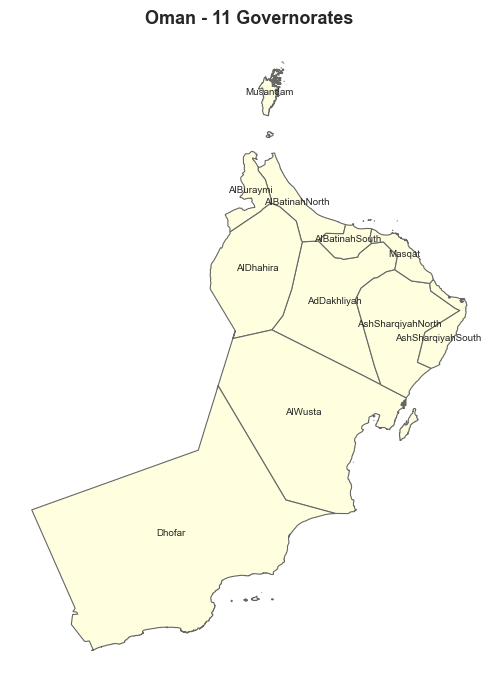

In [3]:
try:
    fig = moh.plot_governorates(title="Oman - 11 Governorates")
    plt.show()
except ImportError as exc:
    print(f"Map unavailable: {exc}")
    print("Install geopandas with:  pip install epidatasets[geo]")

## 4. Available Annual Reports

In [4]:
reports = moh.list_available_reports()
print(f"Report catalogue: {len(reports)} entries ({reports['year'].min()}-{reports['year'].max()})")
print(reports.tail(5).to_string(index=False))

Report catalogue: 42 entries (1983-2024)
 year                          title                                           expected_url notes
 2020 Oman Annual Health Report 2020 https://moh.gov.om/media/annual-health-report-2020.pdf  None
 2021 Oman Annual Health Report 2021 https://moh.gov.om/media/annual-health-report-2021.pdf  None
 2022 Oman Annual Health Report 2022 https://moh.gov.om/media/annual-health-report-2022.pdf  None
 2023 Oman Annual Health Report 2023 https://moh.gov.om/media/annual-health-report-2023.pdf  None
 2024 Oman Annual Health Report 2024 https://moh.gov.om/media/annual-health-report-2024.pdf  None


## 5. Download a Report (or Use Sample Data)

Live PDF download depends on MOH server availability. The accessor probes multiple URL patterns and falls back gracefully.

In [5]:
report = moh.get_annual_report(year=2022)

if report["error"]:
    print(f"Download issue: {report['error']}")
    print("Using built-in sample data for the remainder of this notebook.")
    USE_LIVE = False
else:
    print(f"Downloaded: {report['pdf_path']}")
    USE_LIVE = True

sample = moh.get_sample_health_data()

Download issue: HTTPSConnectionPool(host='moh.gov.om', port=443): Max retries exceeded with url: /media/annual-health-report-2022.pdf (Caused by NameResolutionError("HTTPSConnection(host='moh.gov.om', port=443): Failed to resolve 'moh.gov.om' ([Errno -2] Name or service not known)"))
Using built-in sample data for the remainder of this notebook.


## 6. Health Status Indicators

Health indicators: 10 found
               indicator   value  year                    unit
         life_expectancy    77.5  2022                   years
   infant_mortality_rate     8.2  2022   per 1,000 live births
maternal_mortality_ratio    12.6  2022 per 100,000 live births
   under5_mortality_rate    10.1  2022   per 1,000 live births
        crude_death_rate     3.1  2022    per 1,000 population
        crude_birth_rate    22.4  2022    per 1,000 population
    total_fertility_rate     2.7  2022      children per woman
           hospital_beds  6983.0  2022                   total
              physicians  9508.0  2022                   total
                  nurses 21500.0  2022                   total


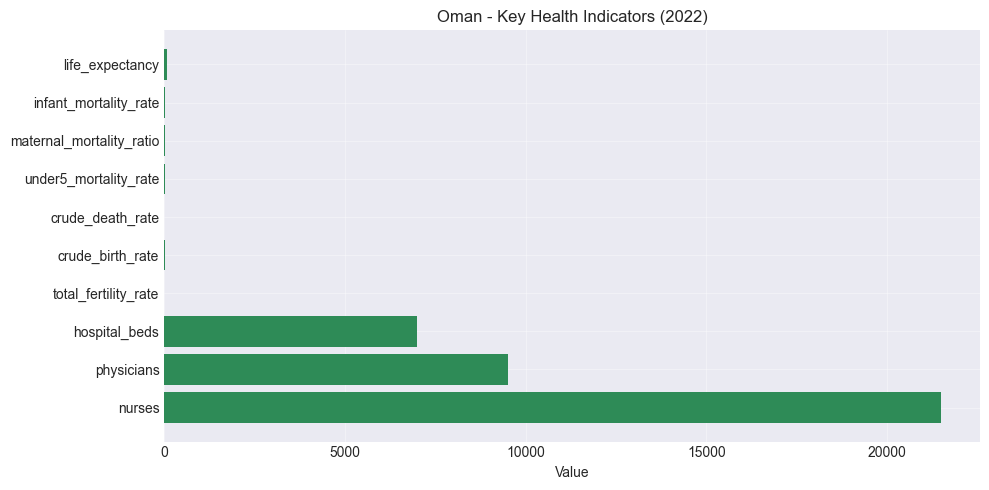

In [6]:
if USE_LIVE and report.get("pdf_path"):
    indicators = moh.extract_health_indicators(report["pdf_path"])
else:
    indicators = sample["indicators"]

if indicators.empty:
    indicators = sample["indicators"]

print(f"Health indicators: {len(indicators)} found")
print(indicators.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
numeric = indicators[indicators["value"] < 100000].copy()
bars = ax.barh(numeric["indicator"], numeric["value"], color="seagreen")
ax.set_xlabel("Value")
ax.set_title("Oman - Key Health Indicators (2022)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 7. Morbidity and Mortality

Diseases tracked: 15
                        disease  cases  deaths  year
                        Malaria   2745       2  2022
                   Tuberculosis    312       5  2022
                    Hepatitis A    189       0  2022
                    Hepatitis B    145       1  2022
                         Dengue     86       0  2022
Crimean-Congo Hemorrhagic Fever     34       6  2022
                        Measles     12       0  2022
                      Influenza   5420      18  2022
                        Typhoid     67       0  2022
                  Leishmaniasis     23       0  2022
              Diabetes mellitus 125000     890  2022
           Circulatory diseases  34500    2100  2022
            Malignant neoplasms   2800     620  2022
           Respiratory diseases  18900     340  2022
                       Injuries  45000     950  2022


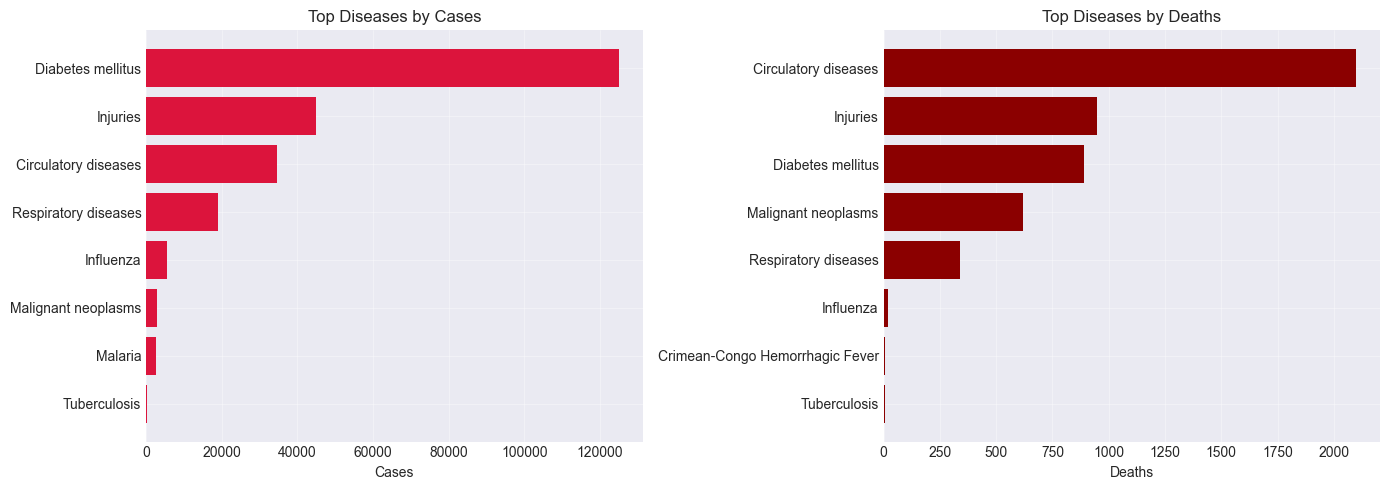

In [7]:
if USE_LIVE and report.get("pdf_path"):
    morbidity = moh.extract_morbidity_mortality(report["pdf_path"])
else:
    morbidity = sample["morbidity"]

if morbidity.empty:
    morbidity = sample["morbidity"]

print(f"Diseases tracked: {len(morbidity)}")
print(morbidity.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top_cases = morbidity.nlargest(8, "cases")
axes[0].barh(top_cases["disease"], top_cases["cases"], color="crimson")
axes[0].set_xlabel("Cases")
axes[0].set_title("Top Diseases by Cases")
axes[0].invert_yaxis()

top_deaths = morbidity.nlargest(8, "deaths")
axes[1].barh(top_deaths["disease"], top_deaths["deaths"], color="darkred")
axes[1].set_xlabel("Deaths")
axes[1].set_title("Top Diseases by Deaths")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 8. Health Service Utilization

              metric   value  year
   outpatient_visits 8234567  2022
inpatient_admissions  234567  2022
           surgeries   89234  2022
          deliveries   67890  2022
    emergency_visits 1567890  2022
       dental_visits  456789  2022


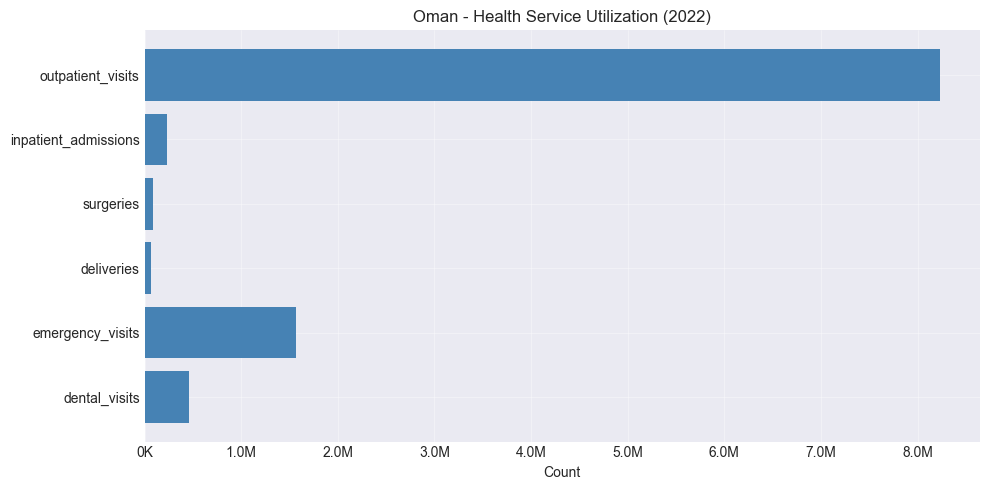

In [8]:
if USE_LIVE and report.get("pdf_path"):
    utilization = moh.extract_health_utilization(report["pdf_path"])
else:
    utilization = sample["utilization"]

if utilization.empty:
    utilization = sample["utilization"]

print(utilization.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(utilization["metric"], utilization["value"], color="steelblue")
ax.set_xlabel("Count")
ax.set_title("Oman - Health Service Utilization (2022)")
ax.invert_yaxis()
ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K")
)
plt.tight_layout()
plt.show()

## 9. Governorate-level Health Data

Governorates: 11
        governorate  population  outpatient_visits  inpatient_admissions  physicians
             Masqat     1450000            2100000                 62000        3100
             Dhofar      416000             890000                 28000        1200
      Ad Dakhiliyah      386000             780000                 25000         950
   Al Batinah North      683000            1350000                 38000        1450
   Al Batinah South      423000             820000                 22000         890
Ash Sharqiyah North      265000             530000                 15000         620
Ash Sharqiyah South      312000             640000                 18000         710
        Ad Dhahirah      284000             560000                 16000         680
         Al Buraimi      118000             245000                  7000         340
           Al Wusta       48000              95000                  2500         150
           Musandam       45000              880

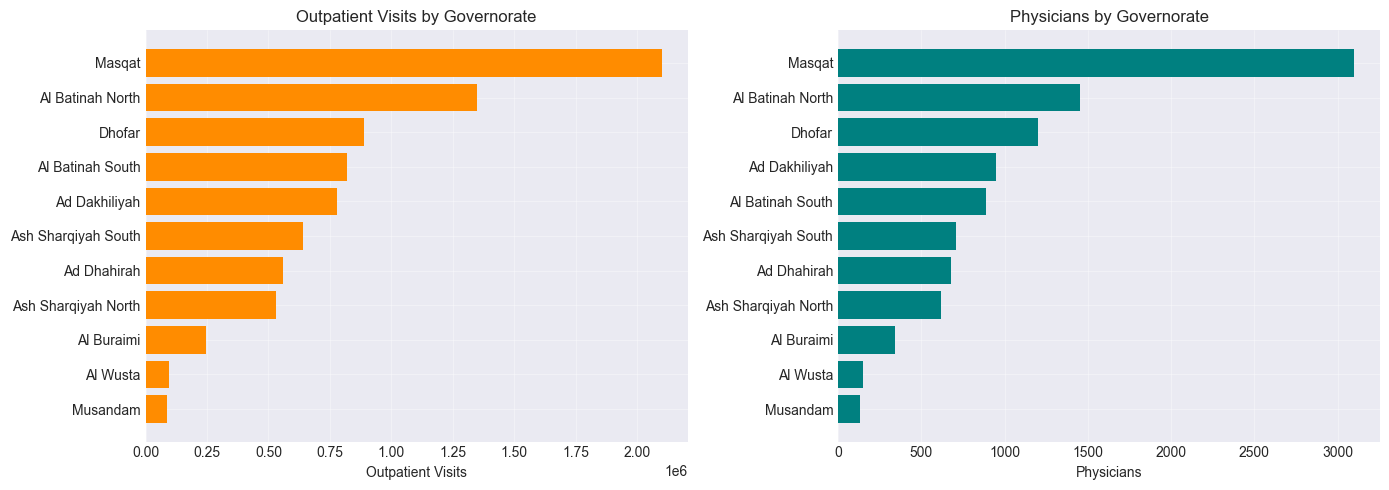

In [9]:
if USE_LIVE and report.get("pdf_path"):
    gov_data = moh.get_governorate_data(report["pdf_path"])
else:
    gov_data = sample["governorate"]

if gov_data.empty:
    gov_data = sample["governorate"]

print(f"Governorates: {len(gov_data)}")
print(gov_data.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gov_data_sorted = gov_data.sort_values("outpatient_visits", ascending=True)
axes[0].barh(gov_data_sorted["governorate"], gov_data_sorted["outpatient_visits"], color="darkorange")
axes[0].set_xlabel("Outpatient Visits")
axes[0].set_title("Outpatient Visits by Governorate")

gov_data_sorted2 = gov_data.sort_values("physicians", ascending=True)
axes[1].barh(gov_data_sorted2["governorate"], gov_data_sorted2["physicians"], color="teal")
axes[1].set_xlabel("Physicians")
axes[1].set_title("Physicians by Governorate")

plt.tight_layout()
plt.show()

## 10. Governorate Choropleth Map

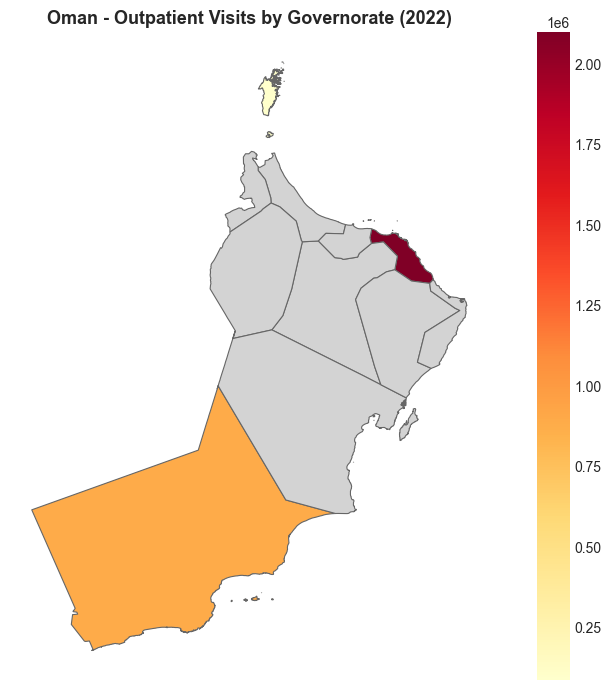

In [10]:
try:
    fig = moh.plot_governorates(
        data=gov_data,
        column="outpatient_visits",
        title="Oman - Outpatient Visits by Governorate (2022)",
        cmap="YlOrRd",
        legend=True,
    )
    plt.show()
except ImportError as exc:
    print(f"Map unavailable: {exc}")

## 11. Population-per-Physician Ratio

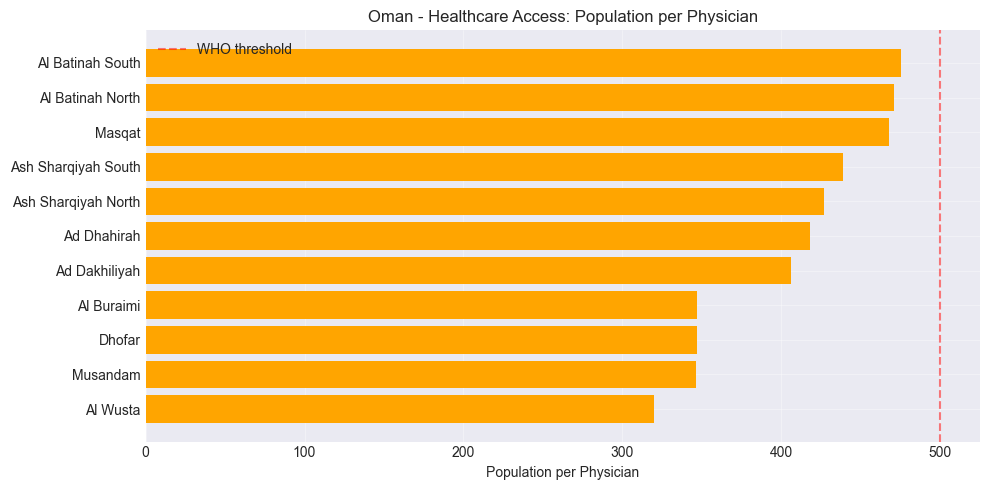

In [11]:
gov_data["pop_per_physician"] = (gov_data["population"] / gov_data["physicians"]).round(0).astype(int)
gov_sorted = gov_data.sort_values("pop_per_physician", ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ["green" if v < 300 else ("orange" if v < 500 else "red") for v in gov_sorted["pop_per_physician"]]
ax.barh(gov_sorted["governorate"], gov_sorted["pop_per_physician"], color=colors)
ax.set_xlabel("Population per Physician")
ax.set_title("Oman - Healthcare Access: Population per Physician")
ax.axvline(x=500, color="red", linestyle="--", alpha=0.5, label="WHO threshold")
ax.legend()
plt.tight_layout()
plt.show()

## 12. Other Statistical Reports

In [12]:
try:
    other = moh.get_other_statistical_reports()
    print(f"Other reports found: {len(other)}")
    if not other.empty:
        print(other.head(10).to_string(index=False))
    else:
        print("  No additional reports discovered (MOH site may be unreachable).")
except Exception as exc:
    print(f"Could not fetch: {exc}")

Failed to fetch statistics page: HTTPSConnectionPool(host='moh.gov.om', port=443): Max retries exceeded with url: /en/statistics/ (Caused by NameResolutionError("HTTPSConnection(host='moh.gov.om', port=443): Failed to resolve 'moh.gov.om' ([Errno -2] Name or service not known)"))


Other reports found: 0
  No additional reports discovered (MOH site may be unreachable).


## Summary

This notebook demonstrated the `OmanMOHAccessor`:

| Feature | Method | Status |
|---|---|---|
| Governorate map | `plot_governorates()` | geopandas choropleth |
| Report catalogue | `list_available_reports()` | 1983-2024 |
| PDF download | `get_annual_report(year)` | auto-probes URLs |
| Sample data | `get_sample_health_data()` | offline fallback |
| Health indicators | `extract_health_indicators()` | regex from PDF |
| Morbidity | `extract_morbidity_mortality()` | disease extraction |
| Utilization | `extract_health_utilization()` | service metrics |
| Governorate data | `get_governorate_data()` | subnational stats |

**Documentation:**
- **MOH Portal**: https://moh.gov.om/en/statistics/annual-health-reports/
- **GHDX Catalog**: https://ghdx.healthdata.org/series/oman-annual-health-report